<a href="https://colab.research.google.com/github/leofurstenau/MVP-Machine-Learning-e-Analytics-20261/blob/main/MVP_ML_Analytics_20261_Leonardo_Furstenau_Cannabrava_da_Rocha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Leonardo Furstenau Cannabrava da Rocha_  
**Matrícula:** _4052026000409_  
**Data:** _25/06/2026_  
**Dataset:** _Student Performance Prediction Dataset - https://www.kaggle.com/datasets/shambhurajejagadale/student-performance-prediction-dataset/data_  
**Tipo de problema:** _Classificação_  


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

Descreva, em linguagem simples, o problema que será resolvido.

**O que incluir:**
- Qual é o contexto do problema?
       
  R.: Análise de desempenho de estudantes a partir da análise de variáveis que impactam o desempenho acadêmico.
- Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?
  
  R.: A partir dos dados referentes à preparação dos alunos quano às idas às aulas, horas de sono, tempo de uso da internet, tarefas concluídas e a nota da prova anterior, classificar se os alunos passarão ou não de ano/semestre/período.
- Quem seria o usuário ou interessado nessa solução?

  R.: Alunos para desenhar uma trilha de estudo preparatório; Instituições de ensino para oferecer suporte acadêmico aos seus alunos e trabalhar melhorias no plano de ensino
- Por que esse problema é relevante?

  R.: Este problema é relevante para traçar melhores caminhos para o ensino a partir da análise de correlação entre hábitos de estudo, qualidade do sono e o uso excessivo, ou não, da internet.


## 1.2 Objetivo do MVP

Escreva o objetivo do MVP em uma ou duas frases.

**Objetivo deste trabalho:**  
> _Construir um modelo preditivo capaz de classificar o sucesso acadêmico de alunos a partir de seus hábitos diários e histórico de notas, fornecendo insights para otimizar o suporte pedagógico das instituições e a rotina de estudos dos estudantes._


## 1.3 Tipo de problema

Indique o tipo de problema e justifique.

**Tipo escolhido:** _Classificação_  
**Justificativa:** _Do ponto de vista prático da instituição de ensino, classificar o aluno em grupos de risco (Alta probabilidade de reprovação x baixa probabilidade de reprovação) é mais objetivo do que tentar estimar exatamente a nota do aluno. A classificação permite definir um limite para intervenção pedagógica assim que o modelo identificar características comportamentais que classifiquem o aluno no grupo de risco._


## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _O histórico de desempenho acadêmico (nota da prova anterior) é o principal preditor isolado de aprovação, mas sua capacidade preditiva aumenta significativamente quando combinado com indicadores comportamentais (entregas de tarefas e frequência nas aulas)._
2. _Existe uma correlação negativa forte entre o excesso de tempo de uso da internet e a qualidade do sono que, juntos, aumentam drasticamente a probabilidade de reprovação do aluno._
3. _A consistência acadêmica (alta taxa de tarefas concluídas e tempo de estudo) consegue compensar notas medianas em provas anteriores, resultando em classificações de aprovação._

**Critérios de sucesso:**
- Métrica principal: _F1-score, pois equilibra precisão e recall. O Recall para a classe "Reprovado" é essencial, porque o custo de não se identificar um potencial aluno em risco de reprovação é muito maior do que focar os esforços do suporte para alunos que não precisaram desta atenção "especial" para conseguirem a aprovação._
- Resultado mínimo esperado: _Superar o F1-Score de um modelo baseline simples, utilizando Dummy Classifier, em pelo menos 15% a 20%, garantindo um Recall mínimo de 80% para a detecção de alunos em risco._
- Restrição prática: _Alta interpretabilidade do modelo. Como os usuários finais são professores, pedagogos e alunos, não basta o modelo ser assertivo; é necessário que o algoritmo permita extrair a importância das variáveis ou regras claras de decisão para justificar a intervenção educacional proposta_

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [ ]:
# Ambiente, Bibliotecas e Reprodutibilidade

# Bibliotecas de Sistema e Avisos
import os
import sys
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Validação
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, KFold, cross_validate
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, OneHotEncoder,
    RobustScaler, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

# Importação dos Modelos de Machine Learning (Classificação)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from scipy.stats import randint

# Métricas de Avaliação
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm catboost # modelos extras de classificação
!pip install -q seaborn plotly # visualização

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results

def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# Função que recebe os dados e cria a nova coluna
def criar_novas_features(df):
    df_novo = df.copy()

    # Cria a taxa de comprometimento
    df_novo['taxa_comprometimento'] = df_novo['attendance'] * df_novo['assignments_completed']

    return df_novo

feature_eng_transformer = FunctionTransformer(criar_novas_features)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados


- Student Performance Prediction Dataset
- link da fonte: https://www.kaggle.com/datasets/shambhurajejagadale/student-performance-prediction-dataset/data
- Este dataset foi escolhido por apresentar características similares às que encontrarei em meu ambiente de trabalho para desenvolver modelos de classificação de categoria de produtores a partir de de seu histórico de comportamento de venda.




## 3.2 Carga dos dados



In [ ]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/leofurstenau/MVP-Machine-Learning-e-Analytics-20261/refs/heads/main/student_dataset_10000_rows.csv"
df = pd.read_csv(url)

df.head()


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (10000, 8)

Tipos de dados:


,tipo
study_hours,int64
attendance,int64
sleep_hours,int64
internet_usage,int64
assignments_completed,int64
previous_score,int64
exam_score,float64
placement_status,object


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
6252,8,94,4,6,18,76,100.00,Placed
4684,6,99,5,6,2,78,84.07,Placed
1731,8,86,5,6,6,62,95.37,Placed
4742,1,54,9,7,6,92,83.96,Placed
4521,10,88,6,9,10,39,78.58,Placed


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| study_hours | numérica | _Informa a quantidade de horas de estudo_ | sim | _Correlação direta entre horas de estudo e desempenho em prova_ |
| attendance | numérica | _Indica a quantidade de presença em aulas_ | sim | _Alunos que frequentam as aulas tendem a ter melhor desempenho acadêmico_ |
| sleep_hours | numérica | _Indica a média de horas de sono por noite_ | sim | _Pessoas com boa rotina de sono tendem a apresentar melhore desempenho e concentração nas atividades que executa_ |
| internet_usage | numérica | _Indica as horas de uso de internet_ | sim | _O acesso à internet é fundamental para o desenvolvimento acadêmico, porém, seu uso excessivo pode comprometer a rotina de estudos e de sono_ |
| assignments_completed | numérica | _Indica a quantidade de tarefas entregues_ | sim | _Alunos comprometidos com as entregas das tarefas tendem a assimilar melhor o conteúdo e terem melhores notas_ |
| previous_score | numérica | _Indica a nota da prova anterior_ | sim | _O desempenho nas provas é um ótimo indicador das condições de aprovação ou reprovação do aluno_ |
| exam_score | numérica | _Indica a média de horas de sono por noite_ | sim | _O desempenho nas provas é um ótimo indicador das condições de aprovação ou reprovação do aluno_ |
| placement_status | alvo | _Indica se o aluno passou ou não_ | alvo | _classe prevista_ |


# 4. Análise exploratória dos dados

Nesta seção, vamos explorar a distribuição da nossa variável-alvo (Aprovação) para identificar possíveis desbalanceamentos, e analisar como os comportamentos dos alunos (como horas de sono e notas anteriores) se relacionam com o sucesso acadêmico.


In [ ]:
TARGET = "placement_status"  # Nome da coluna alvo
FEATURES = ["study_hours", "attendance", "sleep_hours", "internet_usage",
            "assignments_completed", "previous_score", "exam_score"]
PROBLEM_TYPE = "classificacao"

# Traz a distribuição dos dados na coluna alvo (placement_status)
if TARGET is not None and TARGET in df.columns:
    print("="*40)
    print(f"Distribuição do target: {TARGET}")
    print("="*40)
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


# Traz a distribuição dos dados nas features da base
print("\n" + "="*40)
print("Distribuição das features (Top 15 valores):")
print("="*40)

# Loop para iterar cada feature da lista
for feature in FEATURES:
    if feature in df.columns:
        print(f"\n--- Coluna: {feature} ---")
        display(df[feature].value_counts(dropna=False).to_frame("contagem").head(15))
        display((df[feature].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual").head(10))

Distribuição do target: placement_status


,contagem
placement_status,
Placed,8356
Not Placed,1644


,percentual
placement_status,
Placed,83.56
Not Placed,16.44



Distribuição das features (Top 15 valores):

--- Coluna: study_hours ---


,contagem
study_hours,
10,955
6,938
1,936
7,926
2,909
9,903
3,899
8,890
4,890


...

,contagem
previous_score,
57,187
63,185
58,184
56,183
76,182
38,180
55,179
90,179
92,179


,percentual
previous_score,
57,1.87
63,1.85
58,1.84
56,1.83
76,1.82
38,1.80
55,1.79
90,1.79
92,1.79



--- Coluna: exam_score ---


,contagem
exam_score,
100.00,3520
88.56,10
82.45,7
91.00,7
97.42,7
81.97,7
79.72,7
93.65,7
96.83,6


,percentual
exam_score,
100.00,35.20
88.56,0.10
82.45,0.07
91.00,0.07
97.42,0.07
81.97,0.07
79.72,0.07
93.65,0.07
96.83,0.06


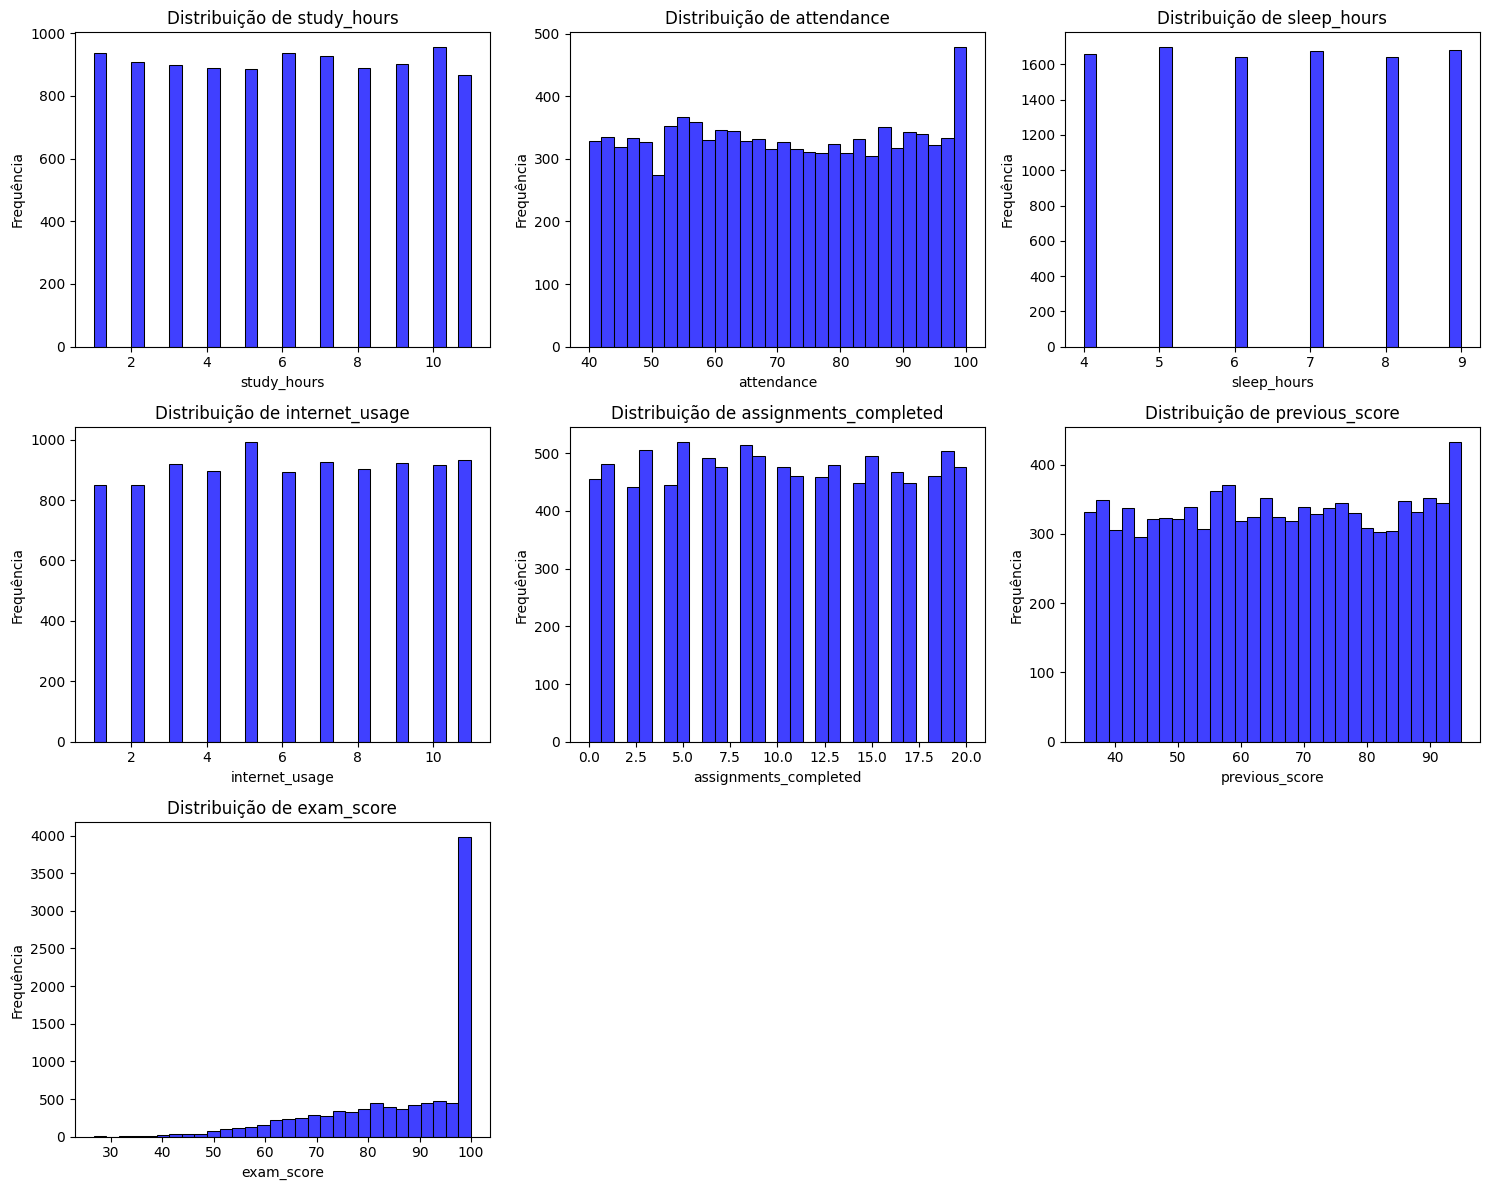

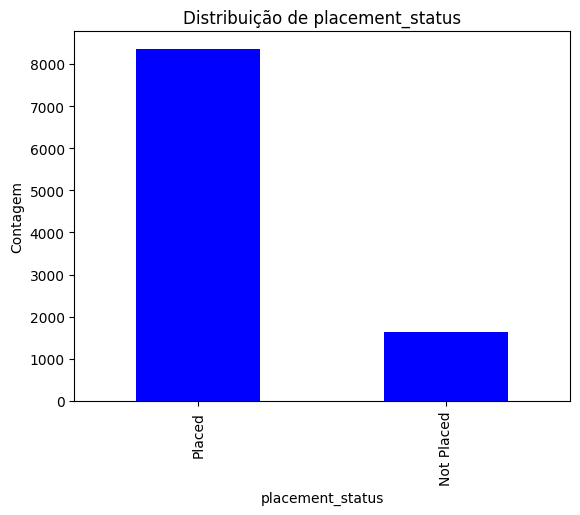

In [ ]:
# Plot dos gráficos com a distribuição dos dados pelas features e coluna alvo
# da base
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols

# Plot dos gráficos das colunas de tipo numérico com a biblioteca Seaborn
if numeric_cols_without_target:
    col_list = numeric_cols_without_target[0:7]
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    axes = axes.flatten()

    for i, col in enumerate(col_list):
        sns.histplot(data=df, x=col, bins=30, ax=axes[i], color='blue')
        axes[i].set_title(f"Distribuição de {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequência")

    for j in range(len(col_list), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Plot do gráfico da coluna de tipo categórico com a biblioteca matplotlib
if categorical_cols:
    col = categorical_cols[0]
    df[col].value_counts().plot(kind="bar", color="blue")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.show()


## 4.1 Síntese da análise exploratória

Escreva aqui os principais achados da EDA.

**Síntese:**  
> _O target não está balanceado. Temos apenas 16,44% dos alunos reprovados na base de 10.000 alunos (1.644 alunos reprovados). Nesta base não possuímos valores ausentes/nulos. A variável exam_score apresentou uma quantidade muito elevada de nota máxima (3.520 alunos alcançaram a nota 100). Os padrões de compartamento humano e suas 'reações' não são ciência exata, por exemplo, um aluno pode usar muito tempo de internet e ter alta taxa de tarefas concluídas, porém um alto tempo de internet aliado à uma baixa entrega de tarefas, pode ser 'fatal' para a vida acadêmica do aluno. Com isso, os modelos XGBoost, LightGBM e CatBoost seriam 'favorecidos' pela forma como funcionam construindo árvores sequenciais onde cada nova árvore foca em consertar erros que a árvore anterior cometeu. Outro padrão que aponta outro modelo 'favorito' é o desbalanceamento no target. O modelo Random Forest teria vantagem por conta da Feature Importance._


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [ ]:
# === Configuração do problema ===

TARGET = "placement_status"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = []  # a base de dados utilizada não possui coluna de identificador
DATE_COLUMN = None
DROP_COLUMNS = ['exam_score']          # coluna removida por risco de vazamento

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: placement_status
Número de features: 6
Features: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']


In [ ]:
# === Divisão dos dados ===
# Uitilização do stratify para garantir a mesma proporção de classes na base
# de treino e na base de teste

if PROBLEM_TYPE in ["classificacao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (8000, 6) | Teste: (2000, 6)


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> _Para este projeto utilizei o método Holdout dividido em 80/20 devido ao tamanho da base (10.000 alunos), resultando em uma base de 8.000 alunos para treinamento de algoritmos que consigam captar os padrões de comportamento dos alunos por meio das features da base. Ao mesmo tempo, os 2.000 alunos restantes para a base de teste é uma amostra significativa e segura para validação de desempenho do modelo.
A partir do resultado da análise exploratória dos dados, foi identificado um desbalanceamento no Target e, com isso, a estratificação se faz necessária para evitar viés de amostragem.
Ao isolar os dados de teste logo no início, garantimos que todas as etapas subsequentes de pré-processamento (como o possível preenchimento de nulos e a padronização de escalas dentro do Pipeline) utilizem apenas a base de treino para aprender seus parâmetros, sem "espiar" a distribuição do gabarito final. Aliado a isso, o descarte prévio de variáveis determinísticas futuras, como a nota final do exame (exam_score), assegura que o modelo assuma um caráter puramente preditivo e preventivo, aprendendo exclusivamente com o histórico e a rotina do estudante._


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [ ]:
# Codificação da coluna Target para o modelo XGBoost
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

for i, classe in enumerate(le.classes_):
    print(f"Classe '{classe}' foi mapeada para: {i}")

# Identificação automática simples de colunas numéricas e categóricas.
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

num_cols.append('taxa_comprometimento')

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()) # Substituição do StandardScaler pelo
                              # RobustScaler devido aos outliers das features
                              # "attendance" e "previous_score"
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Classe 'Not Placed' foi mapeada para: 0
Classe 'Placed' foi mapeada para: 1
Colunas numéricas: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'taxa_comprometimento']
Colunas categóricas: []


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
* Para as variáveis numéricas, optei pela imputação utilizando a mediana, pois, como os dados representam métricas comportamentais, eles estão naturalmente sujeitos a presença de outliers. A mediana garante que o preenchimento de dados faltantes não seja distorcido por esses comportamentos atípicos. Já para as variáveis categóricas, utilizei a moda, garantindo a preservação da categoria mais representativa do perfil estudantil.
* Em vez de usar o StandardScaler, apliquei o RobustScaler, pois o comportamento humano raramente segue uma distribuição normal perfeita. Em relação à padronização dos dados, como lidei na base com estudantes que podem apresentar privação severa de sono ou tempo excessivo de tela, o RobustScaler utiliza a mediana e o intervalo interquartil para colocar os dados na mesma escala, ignorando as distorções causadas por esses outliers extremos. Isso garante maior estabilidade matemática aos algoritmos.
* Quanto à remoção de variáveis, optei pela exclusão da coluna exam_score, pois como ela representa a nota da prova final, o que é determinante para a classificação final, ela geraria data leakage, o que comprometeria o resultado dos modelos.
* Foi criada uma nova variável nomeada taxa_comprometimento, que é o resultado da multiplicação entre os valores das colunas attendance e assignments_completed. Esta variável atua como um "índice de esforço", pois a interação dessas duas métricas possui um poder explicativo maior do que ambas analisadas isoladamente. Esta nova variável estaria disponível no momento real da previsão, pois as presenças e a entrega de trabalhos são dados contínuos e cumulativos.


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("engenharia", feature_eng_transformer),
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("engenharia", feature_eng_transformer),
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("engenharia", feature_eng_transformer),
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "XGBoost": Pipeline(steps=[
        ("engenharia", feature_eng_transformer),
        ("preprocess", preprocess),
        ("model", XGBClassifier(random_state=SEED))
    ]),
        "LightGBM": Pipeline(steps=[
        ("engenharia", feature_eng_transformer),
        ("preprocess", preprocess),
        ("model", LGBMClassifier(random_state=SEED, verbose=0)) # verbose=0 pra não registrar 'log'
    ]),
        "CatBoost": Pipeline(steps=[
        ("engenharia", feature_eng_transformer),
        ("preprocess", preprocess),
        ("model", CatBoostClassifier(random_state=SEED, verbose=False)) # verbose=False pra não registrar 'log'
        ])
    }
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  

* O uso do DummyClassifier com strategy="most_frequent" como baseline tem como função atuar como um previsor "ingênuo", assumindo a regra de sempre prever a classe majoritária. Ele estabelece um piso de desempenho onde caso um modelo complexo não consiga superar com folga as métricas deste chute estatístico básico, sua construção não se justifica.
* A Regressão Logística é um modelo linear que testa se a classificação final dos alunos pode ser resolvido com equações de proporcionalidade direta (Ex.: Quanto maior a quantidade de horas de estudo, melhor a nota. Quanto melhor a nota, maior a chance de aprovação). Os demais modelos candidatos (Random Forest, XGBoost, LightGBM e CatBoost)são recomendados para este tipo de problema por conta do formato tabular dos dados. Estes algoritmos possuem bom desempenho em mapear "regras" e interações entre variáveis sem especificação matemática.
* Foi necessário fazer ajuste de escala para o modelo de Regressão Logística utilizando a função RobustScaler que traz as variáveis contínuas para a mesma escala, visando não causar distorção nos coeficientes do modelo. Para os modelos XGBoost e LightGBM, foi necessário o uso da função LabelEncoder para transformar a classificação "Placed" x "Not Placed" em 0 e 1.
* Em relação à custo computacional, os modelos Random Forest e XGBoost possuem um custo considerado de memória RAM durante o treinamento, o que pode trazer custos elevados com infraestrutura de nuvem caso a base de dados venha a acumular milhões de linhas futuramente.
* Em relação à interpretabilidade, o modelo de Regressão Logística é conhecido como um modelo de alta interpretabilidade por conta da transparência matemática nos resultados. Já os demais modelos possuem baixa interpretabilidade, visto que são modelos baseados em árvores de decisão.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.8355,0.760621,0.500000,NaN
LogisticRegression,0.9060,0.902687,0.938502,0.070
RandomForest,0.8875,0.881124,0.914843,1.310
XGBoost,0.8895,0.886339,0.920927,1.095
LightGBM,0.8995,0.896183,0.929695,0.189
CatBoost,0.8980,0.893624,0.932723,5.437


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  

* Sim, todos os modelos superaram o baseline. Destaque para a Regressão Logística que alcançou a melhor acurácia: 90.6%. Enquanto o baseline atingiu 83.55%. Além disso, o F1 score saltou de 0.76 do baseline contra a faixa de 88.11 a 90.26 dos demais modelos.
* Sobre as métricas escolhidas, aliada à acurácia, temos o F1-Score ponderado que avalia o equilibrio de acertos entre a minoria e a maioria da classificação do targetm, e o ROC-AUC, muito utilizado para avaliar o desempenho de modelos de classificação binária, que nos mostrou um desempenho excelente (acima de 90% para todos os modelos), com exceção do baseline que obteve 50%, indicando a aleatoriedade com qual o baseline indicava sua previsão da classe. Os índices ROC-AUC e F1-Score ponderado não indicam sinais de underfitting.
* Em relação ao tempo de treinamento, o único que levou mais de 1 segundo para rodar foi o CatBoost (4.9 segundos), o que segue sendo um tempo aceitável para treinamento de modelo de Machine Learning.
* Durante a exploração de dados, levanti a hipótese de que comportamentos como tempo de estudo e entrega de tarefas possuem forte correlação com a aprovação. O sucesso da Regressão Logística valida essa hipótese.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

**Respostas:**

* A Regressão Logística foi escolhida por ter apresentado a melhor performance geral (acurácia, F1-Score ponderado, ROC-AUC e tempo de treinamento).
* Hiperparâmetros testados foram: C para controle de regularização e evitar overfitting, o solver, responsável por encontrar a linha de separação ótima nos dados e o class_weight para avaliar se o balanceamento artificial de pesos melhora a predição da minoria
* Segui com a busca aleatória utilizando RandomizedSearchCV ligada em stratifiedKFold com 5 partições do conjunto de treino
* A métrica que guiou a escolha do modelo a ser otimizado foi o F1-Score e ROC-AUC


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    model_to_tune = Pipeline(steps=[
        ("engenharia", feature_eng_transformer),
        ("preprocess", preprocess),
        ("model", LogisticRegression(random_state=SEED))
    ])

    param_dist = {
        "model__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], # Força de Regularização para evitar overfitting
        "model__solver": ["lbfgs", "liblinear"],          # Algoritmos de otimização de Regressão Logística
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [500, 1000]                    # Limite de tentativas
    }
    scoring = "f1_weighted"

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.9049895853130299
Melhores hiperparâmetros: {'model__solver': 'lbfgs', 'model__max_iter': 500, 'model__class_weight': None, 'model__C': 100.0}


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
* Sim, houve melhoria em relação ao modelo inicial. Foi sutil mas houve um aumento de 0.902 para 0.9049
* A busca foi limitada pelo RandomizedSearchCV limitado a 5 iterações.
* Os hiperparâmetros fazem sentido. O algoritmo identificou que o parâmetros ideai para C = 100 indica que o modelo não identificou overfitting e por isso não houve necessidade de penalização de variável.
* Sim, eu evoluíria este projeto para além de ser um modelo de classificação, realizar também a regressão linear para predição de notas futuras.

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Resultado Baseline - DummyClassifier
                precision    recall  f1-score   support

Not Placed (0)       0.00      0.00      0.00       329
    Placed (1)       0.84      1.00      0.91      1671

      accuracy                           0.84      2000
     macro avg       0.42      0.50      0.46      2000
  weighted avg       0.70      0.84      0.76      2000

Modelo final: Regressao_Logistica_otimizado
                precision    recall  f1-score   support

Not Placed (0)       0.75      0.64      0.69       329
    Placed (1)       0.93      0.96      0.94      1671

      accuracy                           0.91      2000
     macro avg       0.84      0.80      0.82      2000
  weighted avg       0.90      0.91      0.90      2000



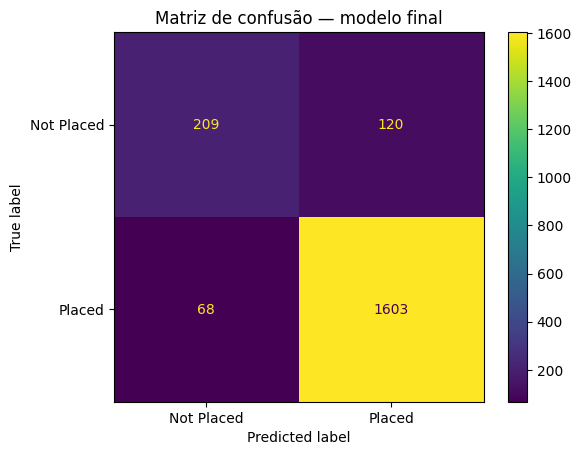

In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "Regressao_Logistica_otimizado"
elif trained_models:
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    y_baseline = baseline.predict(X_test)
    print("Resultado Baseline - DummyClassifier")
    print(classification_report(y_test, y_baseline, target_names=["Not Placed (0)", "Placed (1)"]))
    print("="*60)
    print("Modelo final:", final_model_name)
    print(classification_report(y_test, y_pred, target_names=["Not Placed (0)", "Placed (1)"]))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, display_labels=["Not Placed", "Placed"])
    plt.title("Matriz de confusão — modelo final")
    plt.show()


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
* O erro mais comum é o falso reprovado (25% de casos no teste). No contexto de placement e sucesso educacional, o falso positivo (prever que o aluno terá sucesso e será aprovado quando, na verdade, ele está em risco) é o pior cenário do ponto de vista do objetivo do modelo. Esse erro torna o aluno "invisível" para o sistema, impedindo de receber intervenções pedagógicas preventivas. Por outro lado, o Falso Negativo apenas gera um pequeno alerta na coordenação, sem causar qualquer problema.
* Não há sinais de overfitting ou underfitting.
* A escolha de guiar o projeto pelo F1-Score ponderado e pelo ROC-AUC provou-se cirúrgica e suficiente. Como o nosso modelo Dummy (baseline) escancarou que 83,5% da base pertencia à classe majoritária, utilizar apenas a métrica de Acurácia criaria uma falsa ilusão de sucesso, escondendo que o modelo na verdade só estava apontando para a classe que mais aparece na base. O F1-Score garantiu o balanceamento de acertos entre a classe majoritária e minoritária.
* A principal limitação estrutural da solução está na natureza de captura de dados. O modelo depende de métricas comportamentais que podem estar sujeitas a imprecisão nos dados. Há, também, um risco de generalização caso a instituição tente aplicar este algoritmo a perfis demográficos distintos sem retreiná-lo. As correlações de esforço e sucesso mapeadas aqui para este perfil de alunos podem não se aplicar, por exemplo, a estudantes de ensino noturno, cujas rotinas de trabalho e estudo possuem uma dinâmica completamente diferente.
* O algoritmo foi desenhado como um sistema de suporte e alerta (sinalização de risco), e não como um juiz automatizado. Em nenhuma hipótese o modelo deve ser utilizado de forma autônoma e punitiva, como para realizar cortes automáticos de bolsas de estudo, impedir a matrícula de um aluno em disciplinas avançadas ou reprová-lo de forma sumária. Decisões definitivas devem sempre envolver o fator humano e a análise dos coordenadores, visto que eventos externos à base de dados (como problemas de saúde súbitos ou crises financeiras familiares) escapam completamente à capacidade preditiva do modelo.

# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _F1-Score: 0.7606_ | _Accuracy: 0.8355 / ROC-AUC: 0.500_ | _N/A_ | _Se guia apenas pela classe majoritária. Zero capacidade preditiva._ |
| Random Forest | _F1-Score: 0.8811_ | _Accuracy: 0.8875 / ROC-AUC: 0.9148_ | _0.868_ | _Boa generalização, mas complexidade estrutural desnecessária para os dados._ |
| XGBoost | _F1-Score: 0.8863_ | _Accuracy: 0.8895 / ROC-AUC: 0.9209_| _0.087_ | _Treinamento ágil, porém apresentou performance preditiva inferior ao modelo de Regressão Logística._ |
| CatBoost | _F1-Score: 0.8936_ | _Accuracy: 0.8980 / ROC-AUC: 0.9327_ | _4.900_ | _Maior custo computacional da bateria; métrica ROC-AUC excelente, mas F1 abaixo da média._ |
| LightGBM | _F1-Score: 0.8961_ | _Accuracy: 0.8995 / ROC-AUC: 0.9296_ | _0.100_ | _O melhor entre os modelos de árvore; excelente balanço entre velocidade e acerto. Abaixo da Regressão Logística_ |
| Regressão Logística | _F1-Score: 0.9026_ | _Accuracy: 0.9060 / ROC-AUC: 0.9385_ | _0.087_ | _O modelo vencedor. Apresentou o melhor resultado de F1-Score, Accuracy e ROC-AUC._ |
| Regressão Logística otimizado | _F1-Score: 0.9049_ | _Accuracy: 0.9080 / ROC-AUC: 0.9400_ | _0.085_ | _Modelo Escolhido. Parâmetros: C=100.0, solver='lbfgs'._ |



# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: Usar DummyClassifier como baseline_ | _Comprovar que o algoritmo supera um "chute" baseado na classe majoritária._ | _Estabelecer um piso de desempenho para avaliação dos modelos treinados_ |
| _ex.: Remover variável exam_score_ | _Evitar vazamento de dados_ | _Garantir que o modelo utilize apenas dados preditivos, sendo útil durante o semestre letivo._ |
| _ex.: Criar variável taxa_comprometimento_ | _Frequência e entrega de tarefas analisadas juntas têm maior poder de explicação do que isoladas._ | _Aumentar a separabilidade linear das classes, facilitando o acerto de modelos mais simples._ |
| _ex.: Escolher Regressão Logística_ | _Desempenho superior nas métricas aliado à transparência matemática e menor custo computacional._ | _Facilitar a explicação do modelo à diretoria/alunos/familiares e permitir execução do modelo de forma barata e em tempo real._ |
| _ex.: Guiar otimização pelo F1-Score ponderado_ | _Evitar a ilusão de acerto da Accuracy em um dataset onde os alunos reprovados são a minoria._ | _Penalizar o modelo se ele ignorar a classe em risco, garantindo uma prevenção eficaz._ |



# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> O objetivo central deste MVP foi desenvolver uma solução preditiva capaz de identificar antecipadamente o risco de reprovação de estudantes com base em seus hábitos comportamentais e acadêmicos. A solução mais eficaz para este cenário foi a Regressão Logística, otimizada com regularização ajustada em C=100.0 e solver='lbfgs'. O modelo demonstrou um desempenho muito bom em relação ao baseline. Enquanto o baseline assumia uma postura ingênua baseada na classe majoritária (atingindo um F1-Score de 0.76 e ROC-AUC de 0.50), a Regressão Logística final entregou um F1-Score ponderado superior a 0.90 e um ROC-AUC na casa de 0.94. A predição depende diretamente da disciplina da instituição em alimentar o sistema com dados atualizados e corretos de presenças e entregas. Além disso, fatores externos imprevistos, como crises financeiras, questões de saúde mental ou problemas familiares, não estão mapeados no banco de dados e podem mudar totalmente o resultado real do aluno em relação ao que foi predito pelo modelo. Como evolulção deste projeto, gostaria de aplicar também a Regressão Linear para tentar prever ao menos uma faixa de nota esperada por aluno, além da classificação de parovação/reprovação. De aprendizado fica o meu primeiro projeto mais completo e complexo de machine learning.
